# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error,r2_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import RandomizedSearchCV

# Preprocessing

In [2]:
df = pd.read_csv("flood.csv")
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [3]:
print(df.info())
print("\n")
print(f"The data's shape: {df.shape}")

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerability         

### Summary Statistics
The data's columns all had the same value for their minimum, 25th, 50th, and 75th percentiles. Their max value and standard deviation all fell within the same range. This stood out as strange considering the columns had such different uses in predicting flood probability

In [4]:
df.describe()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000


In [5]:
df.isna().sum()

MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

### Outliers
The datas columns did contain outliers. We decided not to remove any outliers in the columns as we thought they could represent extreme cases and due to the frequency of the outliers we doubted they were errors.

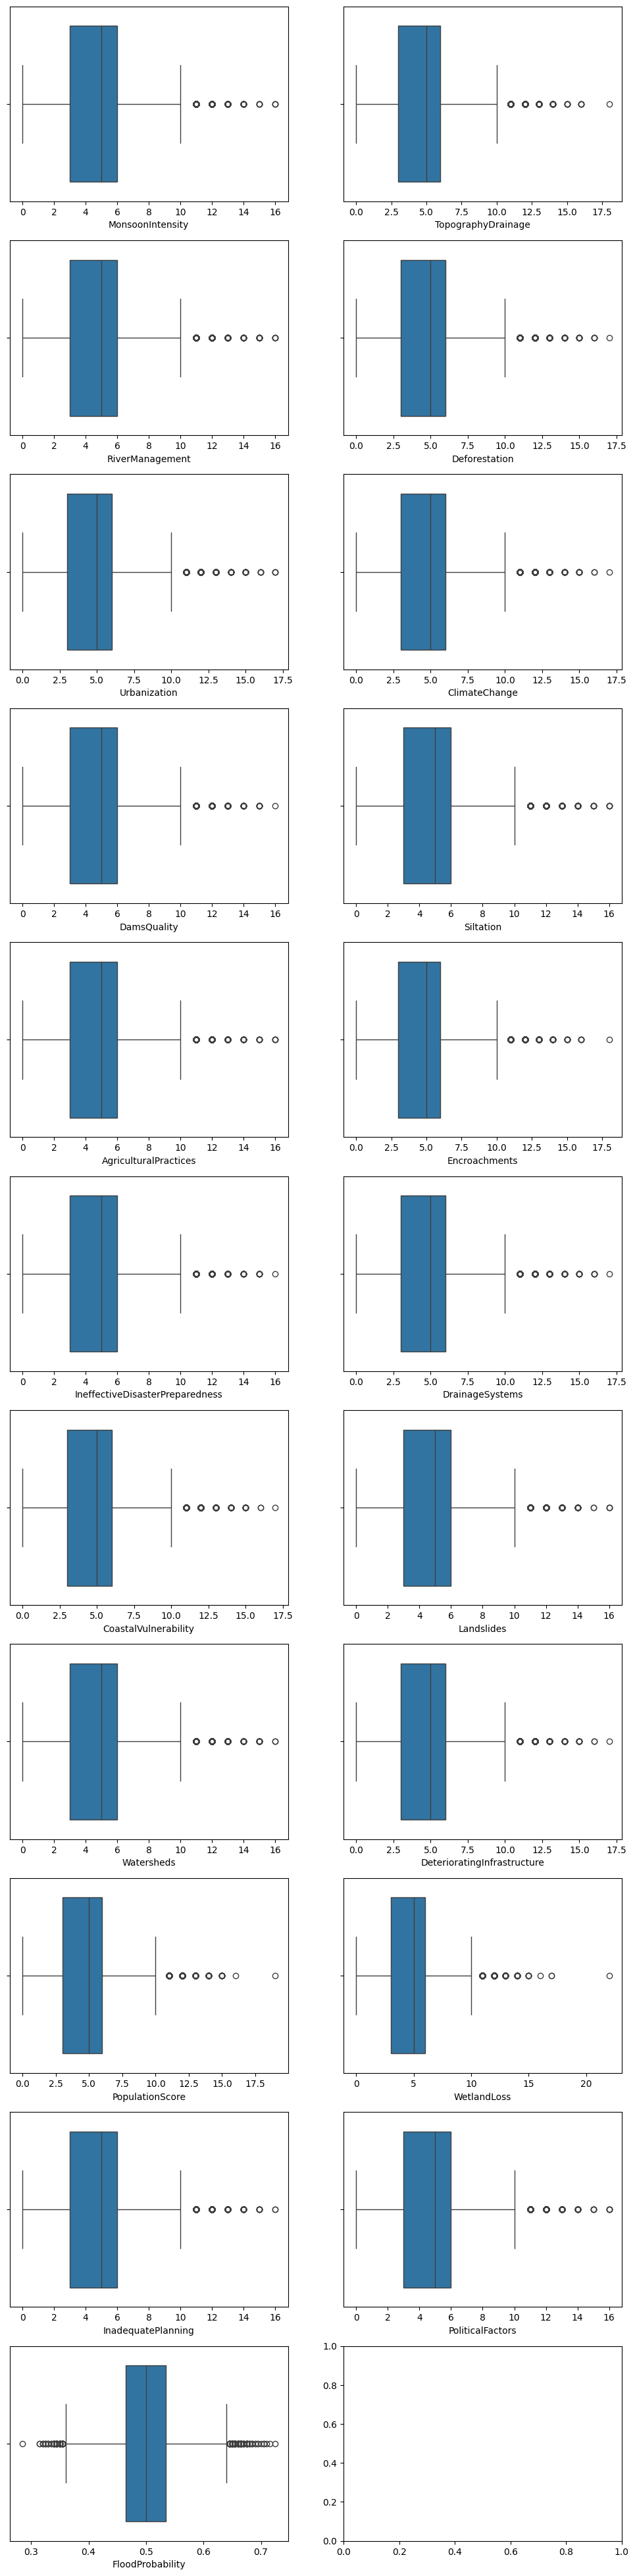

In [6]:
fig, axs = plt.subplots(nrows=11, ncols=2, figsize=(12, 50)) 
axs = axs.flatten()
for i, col in enumerate(df.columns):
    sns.boxplot(data=df, x=col, ax=axs[i])

## Correlation Analysis Using a Correlation Matrix
We used a correlation matrix to visualize how the columns were related. Something noteworthy we found was that they all had incredibly similar correlation coefficients 

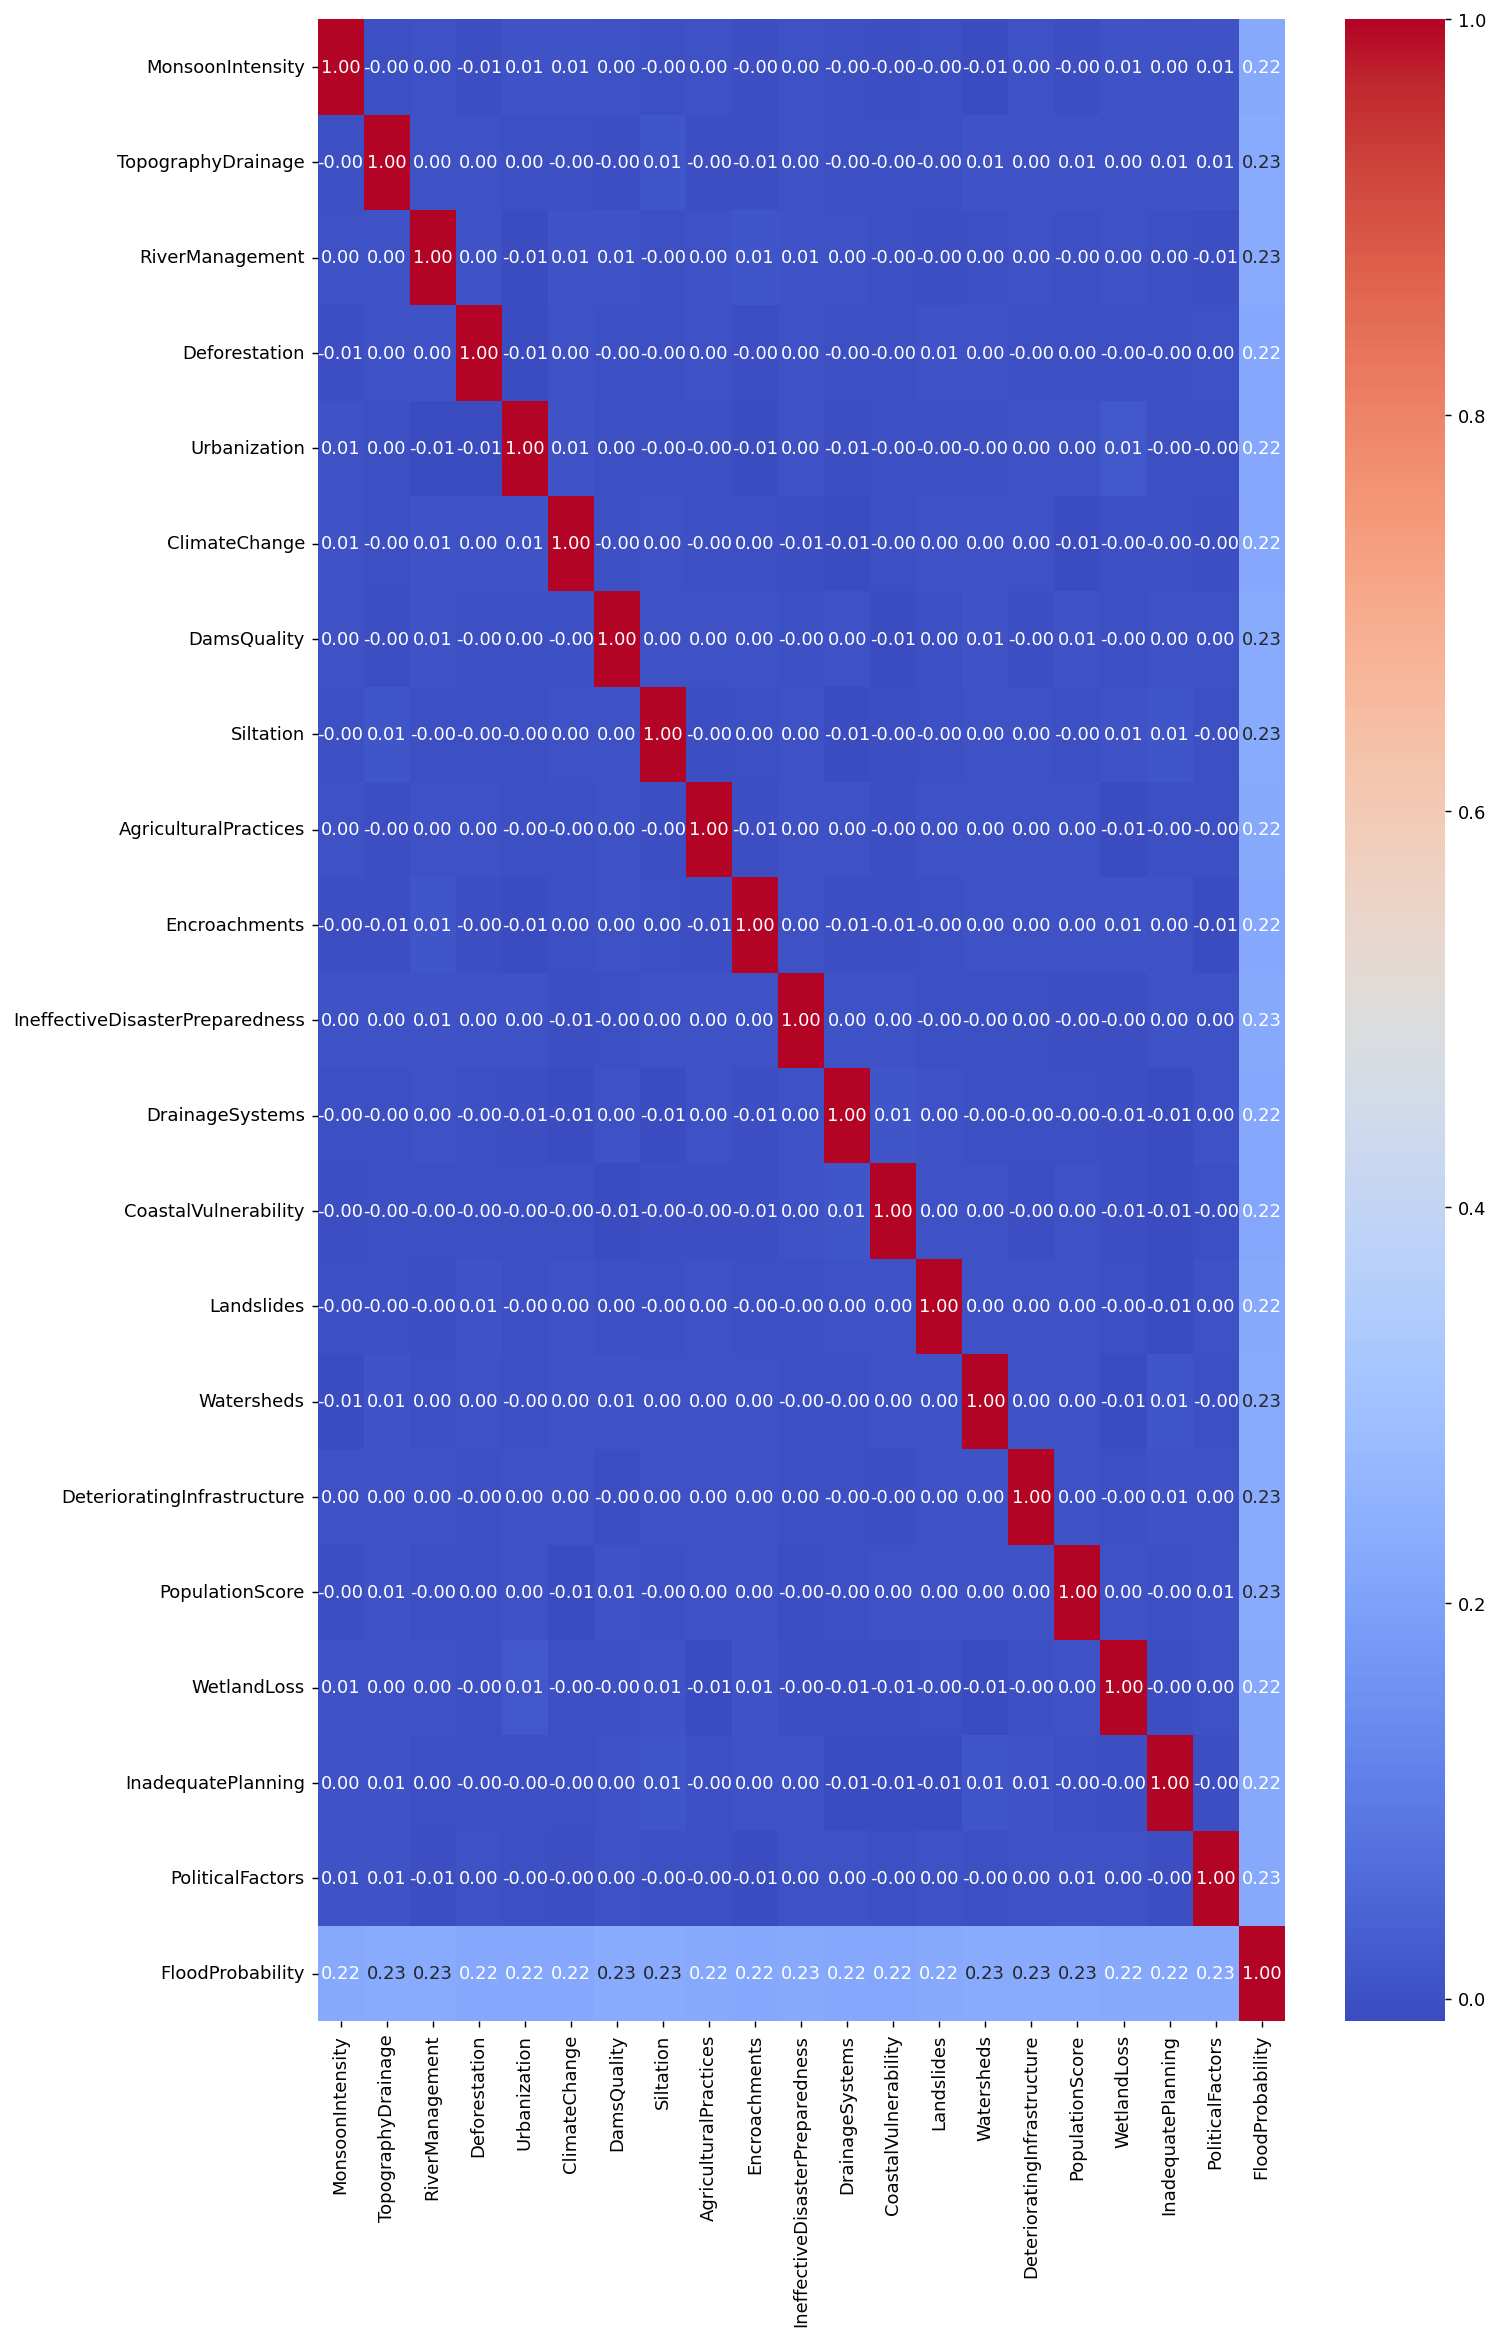

FloodProbability                   1.000000
DeterioratingInfrastructure        0.229444
TopographyDrainage                 0.229414
RiverManagement                    0.228917
Watersheds                         0.228152
DamsQuality                        0.227467
PopulationScore                    0.226928
Siltation                          0.226544
IneffectiveDisasterPreparedness    0.225126
PoliticalFactors                   0.225009
MonsoonIntensity                   0.224081
WetlandLoss                        0.223732
InadequatePlanning                 0.223329
Landslides                         0.222991
AgriculturalPractices              0.221846
ClimateChange                      0.220986
Urbanization                       0.220867
Deforestation                      0.220237
Encroachments                      0.218259
DrainageSystems                    0.217895
CoastalVulnerability               0.215187
Name: FloodProbability, dtype: float64


In [7]:
corr = df.corr()
plt.figure(dpi=130,figsize=(12,20))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['FloodProbability'].sort_values(ascending=False))

## Data Split and Scaling

We chose to use MinMax scaler to scale feature columns to values between 0 and 1. We chose this scaler initially and then experimented with Robust Scaler since its resistant to outliers. We also trained the model on no scaled data and all 3 cases produced similar results

In [8]:
X = df.drop("FloodProbability",axis=1)
y = df["FloodProbability"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=6)
MMscale = MinMaxScaler()
RS = RobustScaler()

X_train_scaled = MMscale.fit_transform(X_train)
X_test_scaled = MMscale.transform(X_test)

X_train_robust = RS.fit_transform(X_train)
X_test_robust = RS.transform(X_test)

# Model Training

### Initial Results
The models we decided to train included:
* Multiple Linear Regression
* Random Forest Regression
* Multilayer Perceptron

The evaluation metrics we considered were:
* Mean Absolute Error: Tells us how off our model was on average giving us an easy to interpret score
* Root Squared Mean Error: The RSME penalizes larger errors heavily so we decided to experiment with it despite our dataset having outliers.
* $R^2$ Score: Explains how much of the variance in the flood probability was explained by our model. Again this gave us an easy to interpret score 
-----------------------------------------------------------------------------------------------------------------------------------------------------

The Random Forest Model and Multiple Linear Regression were trained on both min max scaled data and robust scaler data. Both models had good, near perfect scores with the robust scaled data producing the best results. 

* The score values are incredibly small, almost 0 even, which led us to train another model to see how our results would differ and perform feature selection on columns depending on their correlation to the target variable

In [ ]:
models = {
    "Random Forest Regression" : RandomForestRegressor(random_state=6),
    "Multiple Linear Regression": LinearRegression()
}

for model_name, model in models.items():
    print(f"Training {model_name} with default parameters and MinMax scaled data")
    model.fit(X_train_scaled,y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test,y_pred)
    rmse = root_mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    
    print(f"The mean absolute error for {model_name}: {mae}")
    print(f"The root mean squared error for {model_name}: {rmse}")
    print(f"The R-squared for {model_name}: {r2}")
    print("-"*50)

Training Random Forest Regression with default parameters and MinMax scaled data
The mean absolute error for Random Forest Regression: 0.020380363333333342
The root mean squared error for Random Forest Regression: 0.02595452143333284
The R-squared for Random Forest Regression: 0.7325878832723558
--------------------------------------------------
Training Multiple Linear Regression with default parameters and MinMax scaled data
The mean absolute error for Multiple Linear Regression: 1.6577850203702838e-16
The root mean squared error for Multiple Linear Regression: 2.0955392192046462e-16
The R-squared for Multiple Linear Regression: 1.0
--------------------------------------------------


In [21]:
for model_name, model in models.items():
    print(f"Training {model_name} with default parameters Robust scaled data")
    model.fit(X_train_robust,y_train)
    y_pred_robust = model.predict(X_test_robust)
    mae = mean_absolute_error(y_test,y_pred_robust)
    rmse = root_mean_squared_error(y_test,y_pred_robust)
    r2 = r2_score(y_test,y_pred_robust)
    
    print(f"The mean absolute error for {model_name}: {mae}")
    print(f"The root mean squared error for {model_name}: {rmse}")
    print(f"The R-squared for {model_name}: {r2}")
    print("-"*50)

Training Random Forest Regression with default parameters Robust scaled data
The mean absolute error for Random Forest Regression: 0.020364006666666677
The root mean squared error for Random Forest Regression: 0.02592632429918802
The R-squared for Random Forest Regression: 0.7331686036265606
--------------------------------------------------
Training Multiple Linear Regression with default parameters Robust scaled data
The mean absolute error for Multiple Linear Regression: 6.091978773289005e-16
The root mean squared error for Multiple Linear Regression: 7.607675855381185e-16
The R-squared for Multiple Linear Regression: 1.0
--------------------------------------------------


## MLP Training and Evaluation
We decided to try training an Multi layer perceptron model and see how it'd perform with the data. After seeing how well it performed we decided to tune it to see if we can improve its scores any further using RandomSearchCV. We chose this approach in particular since the model was already performing pretty well so we didn't see the need in something more time consuming like bayesian optimization. The parameters we tuned included the number of hidden layers, the activation function, and the alpha value. 

In [12]:
mlp = MLPRegressor(random_state=6,max_iter=1000,activation="relu")
mlp.fit(X_train_robust, y_train)
y_pred_mlp =mlp.predict(X_test_robust)
mlp_r2 = mlp.score(X_test_robust, y_test) #The score method returns the R2 score
mlp_mae = mean_absolute_error(y_test, y_pred_mlp)
mlp_rsme = root_mean_squared_error(y_test, y_pred_mlp)
print(f"MLP R2 Score: {mlp_r2}")
print(f"MLP MAE: {mlp_mae}")
print(f"MLP RMSE: {mlp_rsme}")


MLP R2 Score: 0.9236559178556977
MLP MAE: 0.01087481541458874
MLP RMSE: 0.013867883150518552


In [13]:
param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (150,)],
    "activation": ["relu", "tanh", "logistic"],
    "alpha": [0.0001, 0.001, 0.01]
}

random_search = RandomizedSearchCV(MLPRegressor(random_state=6), param_grid, n_iter=10, cv=5, random_state=6)

random_search.fit(X_train_robust, y_train)
print(f"The best parameters are: {random_search.best_params_}")
print(f"The best cross-validation score is: {random_search.best_score_}")

The best parameters are: {'hidden_layer_sizes': (150,), 'alpha': 0.001, 'activation': 'logistic'}
The best cross-validation score is: 0.9999942913737379


In [14]:
mlp_tuned = MLPRegressor(**random_search.best_params_, random_state=6)
mlp_tuned.fit(X_train_robust, y_train)
y_pred_tuned =mlp_tuned.predict(X_test_robust)
mlp_r2 = mlp_tuned.score(X_test_robust, y_test) 
tuned_mae= mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = root_mean_squared_error(y_test, y_pred_tuned)
print(f"MLP R2 Score: {mlp_r2}")
print(f"MLP MAE: {tuned_mae}")
print(f"MLP RMSE: {tuned_rmse}")

MLP R2 Score: 0.9999975591464517
MLP MAE: 5.450934551396395e-05
MLP RMSE: 7.841395260355181e-05


### Feature Selection
 Using the correlation matrix above we were able to perform feature selection and test different model performances on a subset containing the most important feature. We chose the MLP model to perform feature selection with since its scores were better than the random forest but not unreasonable like the Mulitple Linear Regression.

In [15]:
df_subset = df[["DeterioratingInfrastructure", "TopographyDrainage","FloodProbability"]]
df_subset_4 = df[["DeterioratingInfrastructure", "TopographyDrainage","RiverManagement","Watersheds","FloodProbability"]]

## Training on Selected Features using MLP
After training on select features we noticed the scores decreased compared to no feature selection. Our selected columns were just the first 2 with the highest correlation at first, then we trained the model on the first 4 columns with the highest correlation. The model trained on the 4 features had better scores.

In [16]:
X_subset = df_subset.drop("FloodProbability", axis=1)
y_subset = df_subset["FloodProbability"]

X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(X_subset, y_subset, test_size=0.3, random_state=6)

X_train_subset_scaled = RS.fit_transform(X_train_subset)
X_test_subset_scaled = RS.transform(X_test_subset)


In [17]:
mlp_subset = MLPRegressor(**random_search.best_params_, random_state=6)
mlp_subset.fit(X_train_subset_scaled, y_train_subset)
y_pred_subset = mlp_subset.predict(X_test_subset_scaled)
mlp_r2_subset = mlp_subset.score(X_test_subset_scaled, y_test_subset)
tuned_mae_subset = mean_absolute_error(y_test_subset, y_pred_subset)
tuned_rmse_subset = root_mean_squared_error(y_test_subset, y_pred_subset)
print(f"MLP R2 Score: {mlp_r2_subset}")
print(f"MLP MAE: {tuned_mae_subset}")
print(f"MLP RMSE: {tuned_rmse_subset}")

MLP R2 Score: 0.08741232825384915
MLP MAE: 0.03807590682480281
MLP RMSE: 0.047946817223535255


In [18]:
X_subset_4 = df_subset_4.drop("FloodProbability", axis=1)
y_subset_4 = df_subset_4["FloodProbability"]

X_train_subset_4, X_test_subset_4, y_train_subset_4, y_test_subset_4 = train_test_split(X_subset_4, y_subset_4, test_size=0.3, random_state=6)

X_train_subset_4_scaled = RS.fit_transform(X_train_subset_4)
X_test_subset_4_scaled = RS.transform(X_test_subset_4)

In [19]:
mlp_subset_4 = MLPRegressor(**random_search.best_params_, random_state=6)
mlp_subset_4.fit(X_train_subset_4_scaled, y_train_subset_4)
y_pred_subset_4 = mlp_subset_4.predict(X_test_subset_4_scaled)
mlp_r2_subset_4 = mlp_subset_4.score(X_test_subset_4_scaled, y_test_subset_4)
tuned_mae_subset_4 = mean_absolute_error(y_test_subset_4, y_pred_subset_4)
tuned_rmse_subset_4 = root_mean_squared_error(y_test_subset_4, y_pred_subset_4)
print(f"MLP R2 Score: {mlp_r2_subset_4}")
print(f"MLP MAE: {tuned_mae_subset_4}")
print(f"MLP RMSE: {tuned_rmse_subset_4}")

MLP R2 Score: 0.1855864363580524
MLP MAE: 0.03592531151702775
MLP RMSE: 0.04529444928399464


### Final Results
We found it unrealistic for multiple linear regression to get a perfect $R^2$ score so despite the model having the highest scores we actually went with the Multilayer Perceptron 

Some of the limitations/concerns we had with the data include:
* The independent feature columns had correlation coeffieicnts that fell between 0.215 and 0.229 meaning they contributed nearly the same amount and were either the same value or very close
* The scores produced by the models even with no tuning were near perfect
    * The perfect $R^2$ scores stood out as strange on the multiple linear regression considering we didn't do much tuning
* The data has no verifiable source on kaggle. As a result we don't know how the data was collected